**Лабораторная Работа №1**

ИСПОЛЬЗОВАНИЕ НЕЙРОННЫХ СЕТЕЙ ПРЯМОГО РАСПРОСТРАНЕНИЯ ДЛЯ РЕШЕНИЯ ЗАДАЧ КЛАССИФИКАЦИИ

Импорт и настройка среды

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

Загрузка датасета

In [10]:
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

data = pd.read_csv('car_evaluation.csv', names=columns)

print(data.head())
print(data.tail())
print(data.info())

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
     buying maint  doors persons lug_boot safety  class
1723    low   low  5more    more      med    med   good
1724    low   low  5more    more      med   high  vgood
1725    low   low  5more    more      big    low  unacc
1726    low   low  5more    more      big    med   good
1727    low   low  5more    more      big   high  vgood
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null 

In [13]:
label_encoders = {}

for column in data.columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

print(data.head())

X = data.drop('class', axis=1)
y = data['class']

print(X.head())
print(y.head())

   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       2      2
   buying  maint  doors  persons  lug_boot  safety
0       3      3      0        0         2       1
1       3      3      0        0         2       2
2       3      3      0        0         2       0
3       3      3      0        0         1       1
4       3      3      0        0         1       2
0    2
1    2
2    2
3    2
4    2
Name: class, dtype: int64


Разделение данных и преобразование в формат PyTorch

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)


X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

(1382, 6)
(346, 6)


Создание DataLoader и архитектуры нейронной сети 

In [17]:
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

class CarNet(nn.Module):
    def __init__(self):
        super(CarNet, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 4)
        )

    def forward(self, x):
        return self.model(x)

Обучение моделей с разными оптимизаторами

In [18]:
def train_model(optimizer_name):

    model = CarNet()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "AdaGrad":
        optimizer = optim.Adagrad(model.parameters(), lr=0.01)

    epochs = 30
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)

    return model, losses

model_sgd, loss_sgd = train_model("SGD")
model_momentum, loss_momentum = train_model("Momentum")
model_adagrad, loss_adagrad = train_model("AdaGrad")

Оценка точностией

In [19]:
def evaluate_model(model):
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = correct / total
    return accuracy


acc_sgd = evaluate_model(model_sgd)
acc_momentum = evaluate_model(model_momentum)
acc_adagrad = evaluate_model(model_adagrad)

print("SGD accuracy:", acc_sgd)
print("SGD + Momentum accuracy:", acc_momentum)
print("AdaGrad accuracy:", acc_adagrad)

SGD accuracy: 0.6878612716763006
SGD + Momentum accuracy: 0.884393063583815
AdaGrad accuracy: 0.7341040462427746


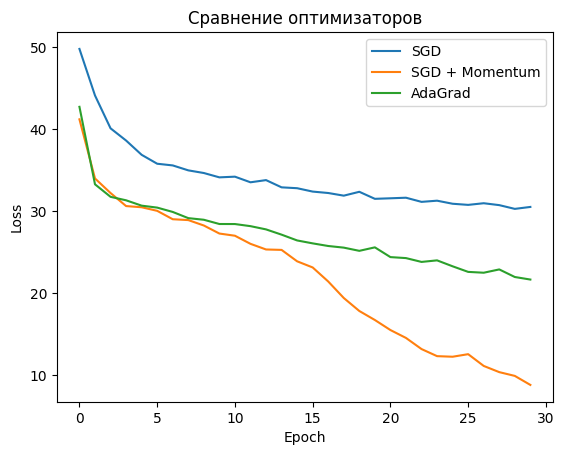

In [20]:
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_momentum, label="SGD + Momentum")
plt.plot(loss_adagrad, label="AdaGrad")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Сравнение оптимизаторов")
plt.legend()

plt.show()

Построение матрицы ошибок

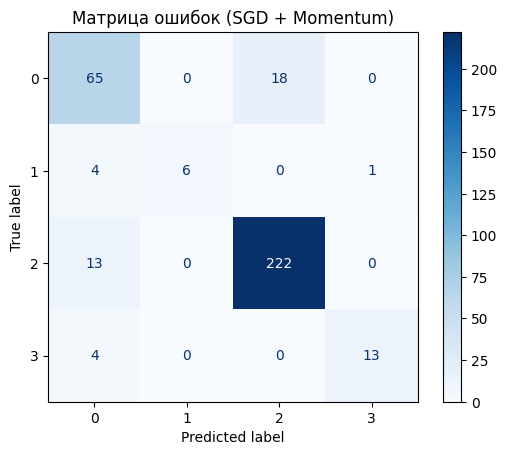

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_momentum(X_batch)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(predicted.numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Матрица ошибок (SGD + Momentum)")
plt.show()